
# EDA: NUREG/KM-0011 Table 4-1 Sample (`nureg_km0011_table4-1_SAMPLE_ONLY.csv`)

**This file is explicitly labeled `SAMPLE_ONLY`** — 21 rows, all from a single
source study (Lowdermilk, 1958). It is far too small for reliable
distribution/correlation conclusions on its own; treat this EDA as a
schema/spot-check against the full-corpus range summary in
`nureg_km0011_table4-2_source_dataset_ranges` rather than a standalone
dataset profile.

## 1. Load Data

`G_kg_m2s` and `CHF_kW_m2` contain thousands-separator commas in the raw CSV
(e.g. `"1,372.7"`) and are cleaned to floats below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/nureg_km0011_table4-1_sample")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "nureg_km0011_table4-1_sample"
SLUG_TITLE = "NUREG/KM-0011 Table 4-1 (Sample)"

df = pd.read_csv(DATA_DIR / "nureg_km0011_table4-1_SAMPLE_ONLY.csv")
for c in ["G_kg_m2s", "CHF_kW_m2"]:
    df[c] = df[c].astype(str).str.replace(",", "", regex=False).astype(float)

NUMERIC_COLS = ["D_m", "L_m", "P_kPa", "G_kg_m2s", "Xchf", "DHin_kJkg", "CHF_kW_m2", "Tin_C"]
CATEGORICAL_COLS = ["Reference"]
TARGET_COL = "CHF_kW_m2"

df.head()

,DataID,D_m,L_m,P_kPa,G_kg_m2s,Xchf,DHin_kJkg,CHF_kW_m2,Tin_C,Reference
0,25,0.004,0.396,100,77.5,0.84,317,442.0,23.94,"Lowdermilk, 1958"
1,26,0.004,0.396,100,142.7,0.79,317,757.0,23.94,"Lowdermilk, 1958"
2,27,0.004,0.396,100,203.9,0.70,317,978.0,23.94,"Lowdermilk, 1958"
3,28,0.004,0.396,100,271.8,0.73,317,1325.0,23.94,"Lowdermilk, 1958"
4,29,0.004,0.396,100,421.3,0.62,317,1798.0,23.94,"Lowdermilk, 1958"


## 2. Data Quality

In [2]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (21, 10)

Dtypes:
DataID         int64
D_m          float64
L_m          float64
P_kPa          int64
G_kg_m2s     float64
Xchf         float64
DHin_kJkg      int64
CHF_kW_m2    float64
Tin_C        float64
Reference     object
dtype: object

Missing values per column:
None

Duplicate rows: 0


## 3. Descriptive Statistics

In [3]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
D_m,21.0,0.004000,1.777563e-18,0.004,0.004,0.004,0.004,0.004
L_m,21.0,0.528000,1.445988e-01,0.396,0.396,0.594,0.594,0.792
P_kPa,21.0,100.000000,0.000000e+00,100.000,100.000,100.000,100.000,100.000
G_kg_m2s,21.0,480.009524,4.424456e+02,77.500,142.700,271.800,679.500,1644.500
Xchf,21.0,0.662857,1.275595e-01,0.420,0.580,0.700,0.750,0.880
DHin_kJkg,21.0,323.333333,6.605553e+00,317.000,317.000,324.000,331.000,331.000
CHF_kW_m2,21.0,1632.238095,1.419953e+03,196.000,536.000,1199.000,2239.000,5236.000
Tin_C,21.0,22.429048,1.575896e+00,20.600,20.600,22.270,23.940,23.940


## 4. Categorical Value Counts

In [4]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- Reference (n_unique=1) ---
Reference
Lowdermilk, 1958    21
Name: count, dtype: int64



## 5. Univariate Distributions

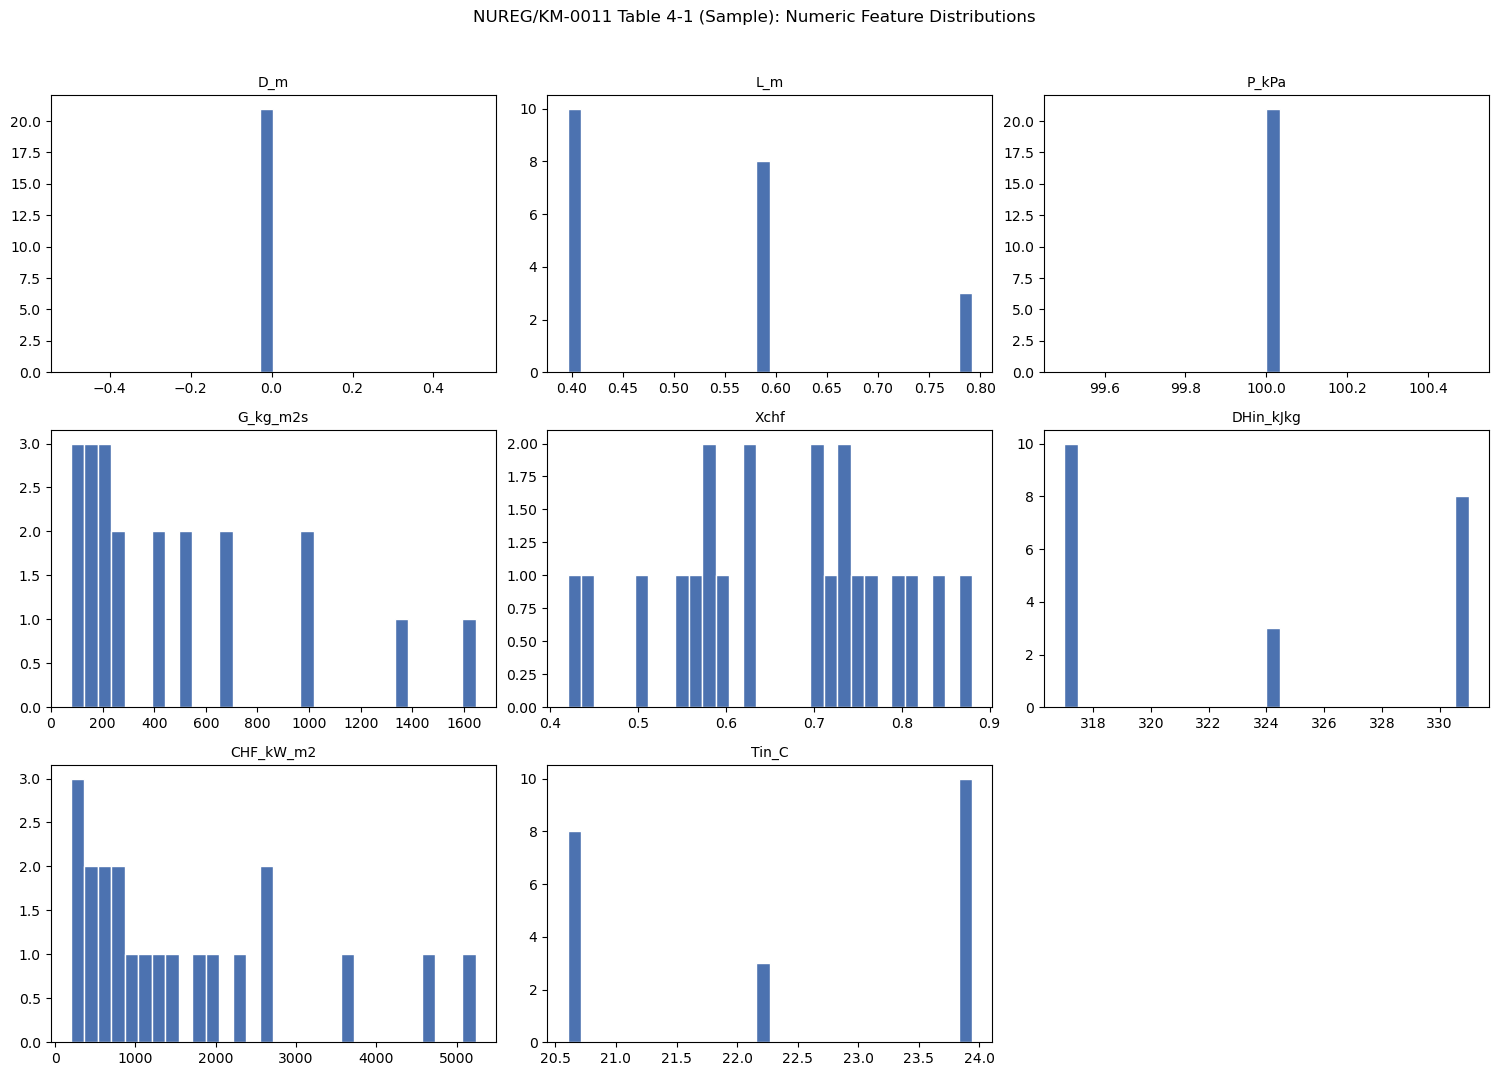

In [5]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [6]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
D_m,0.004,0.004,0.000,0.004,0.004,0,0.000000
L_m,0.396,0.594,0.198,0.099,0.891,0,0.000000
P_kPa,100.000,100.000,0.000,100.000,100.000,0,0.000000
G_kg_m2s,142.700,679.500,536.800,-662.500,1484.700,1,4.761905
Xchf,0.580,0.750,0.170,0.325,1.005,0,0.000000
DHin_kJkg,317.000,331.000,14.000,296.000,352.000,0,0.000000
CHF_kW_m2,536.000,2239.000,1703.000,-2018.500,4793.500,1,4.761905
Tin_C,20.600,23.940,3.340,15.590,28.950,0,0.000000


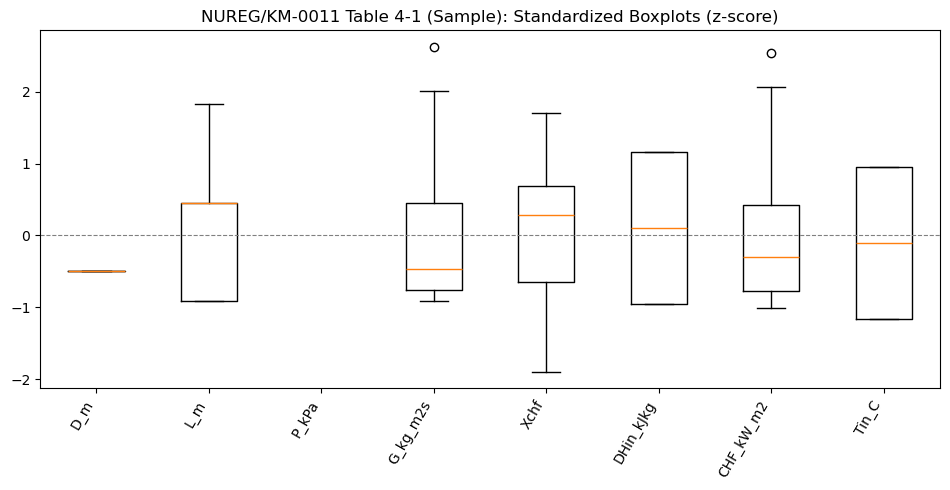

In [7]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

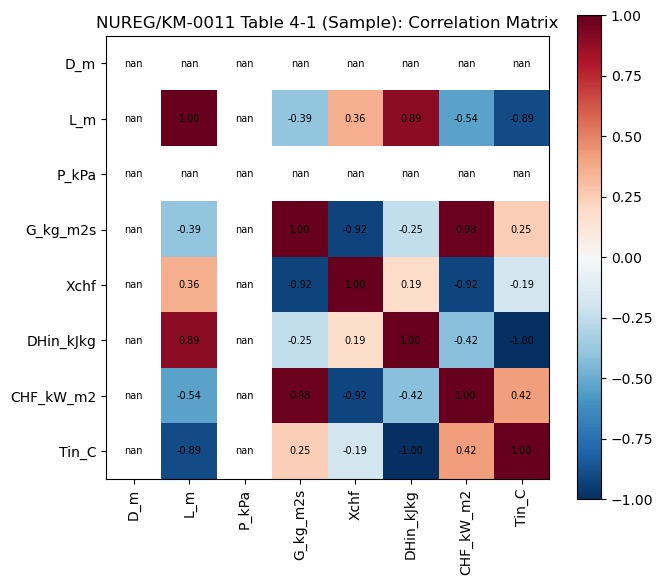

In [8]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

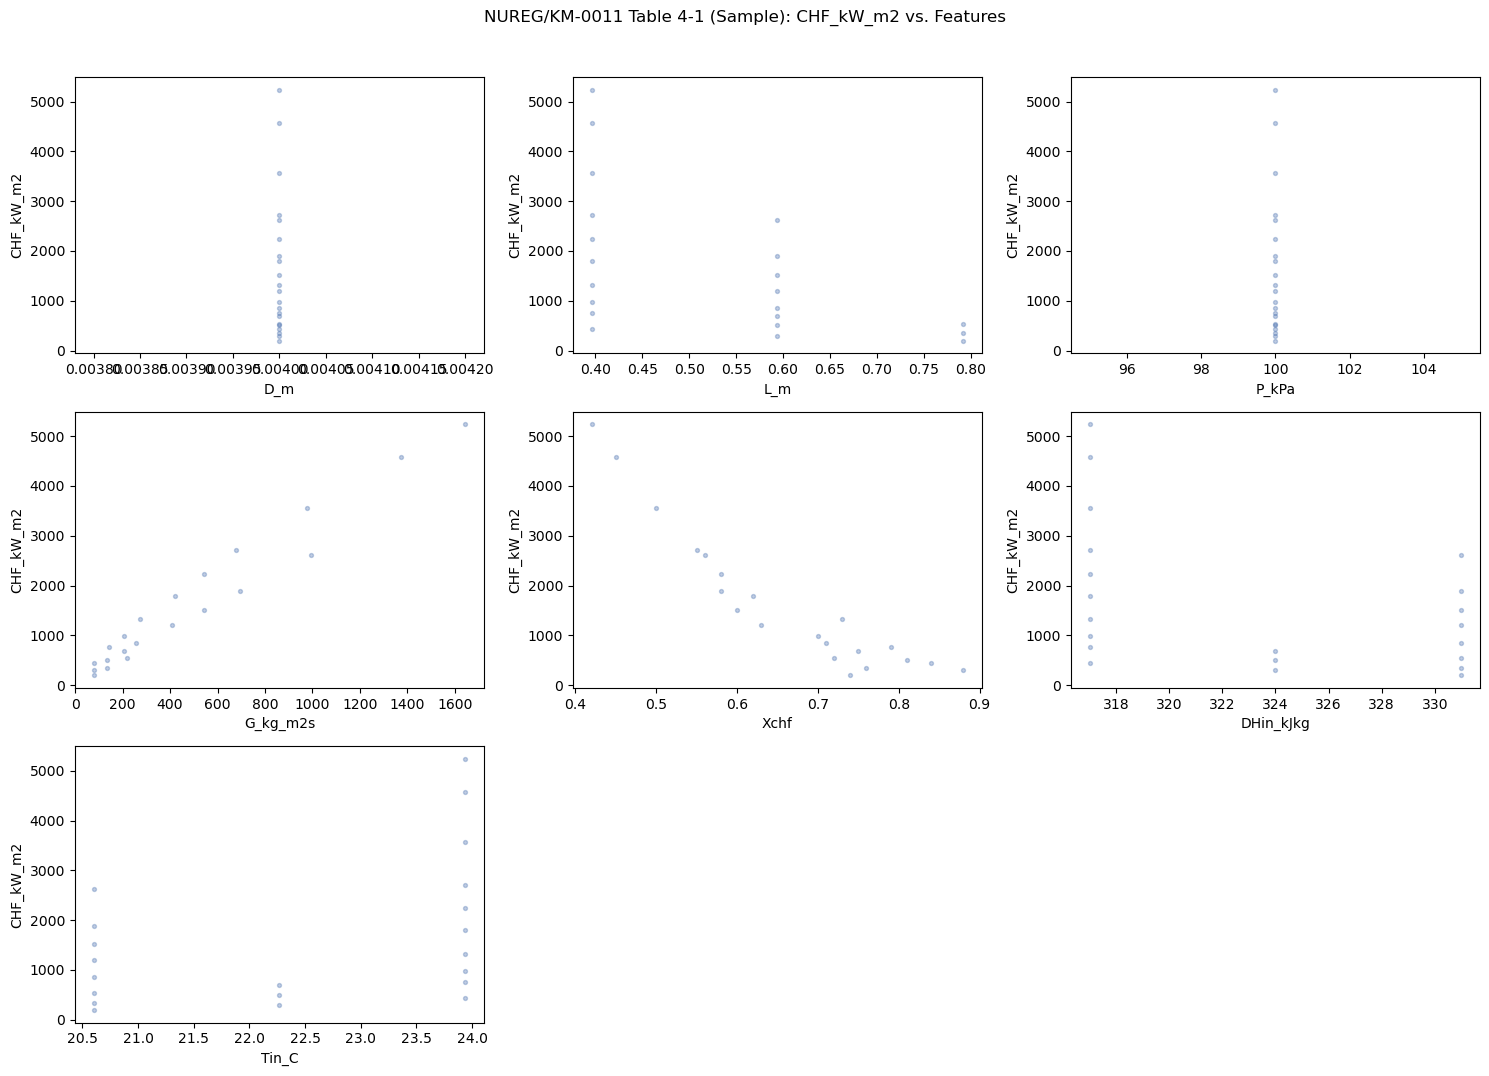

In [9]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

In [10]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")

No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.



## 10. Takeaways

- Only 21 rows / a single `Reference` — histograms and the correlation matrix
  above are illustrative of shape/schema only, not statistically meaningful
  on their own.
- `D_m` and `L_m` are constant across this sample (single tube geometry);
  `CHF_kW_m2` variation here is driven almost entirely by `G_kg_m2s`.
- Cross-referencing against `nureg_km0011_table4-2_source_dataset_ranges`
  requires manual name matching — the two files spell the same source
  differently (`"Lowdermilk, 1958"` here vs.
  `"(1990) Lowdermilk et al. (1958)"` there), so no automated join is
  attempted in this notebook.
